In [1]:
import pandas as pd
import numpy as np

# **Load Dataset**

In [2]:
df=pd.read_csv("/content/task_management_dataset.csv")

# **Dataset Information**

In [3]:
df.head()

,task_id,task_description,task_category,assigned_employee,task_created_date,deadline_in_days,estimated_effort_hours,employee_current_workload_hours,employee_past_completion_rate
0,1,setup CI/CD using Python,DevOps,EMP_22,2024-08-21,22,23,52,0.53
1,2,monitor system using Python,DevOps,EMP_26,2024-08-16,27,11,18,0.64
2,3,assign tasks using Python,Task Management,EMP_20,2024-10-01,11,32,100,0.84
3,4,manage cloud using Python,DevOps,EMP_37,2024-10-29,2,23,16,0.92
4,5,prepare report using Python,Reporting,EMP_1,2024-12-19,7,19,40,0.66


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   task_id                          12000 non-null  int64  
 1   task_description                 12000 non-null  object 
 2   task_category                    12000 non-null  object 
 3   assigned_employee                12000 non-null  object 
 4   task_created_date                12000 non-null  object 
 5   deadline_in_days                 12000 non-null  int64  
 6   estimated_effort_hours           12000 non-null  int64  
 7   employee_current_workload_hours  12000 non-null  int64  
 8   employee_past_completion_rate    12000 non-null  float64
dtypes: float64(1), int64(4), object(4)
memory usage: 843.9+ KB


In [5]:
df.describe()

,task_id,deadline_in_days,estimated_effort_hours,employee_current_workload_hours,employee_past_completion_rate
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000
mean,6000.50000,15.455250,20.506083,85.111333,0.725670
std,3464.24595,8.618267,11.542966,43.507779,0.129357
min,1.00000,1.000000,1.000000,10.000000,0.500000
25%,3000.75000,8.000000,11.000000,48.000000,0.610000
50%,6000.50000,15.000000,20.000000,85.000000,0.730000
75%,9000.25000,23.000000,31.000000,123.000000,0.840000
max,12000.00000,30.000000,40.000000,160.000000,0.950000


In [6]:
df.isnull().sum()

,0
task_id,0
task_description,0
task_category,0
assigned_employee,0
task_created_date,0
deadline_in_days,0
estimated_effort_hours,0
employee_current_workload_hours,0
employee_past_completion_rate,0


# **Exploratory Data Analysis**

In [7]:
df['task_category'].unique()

array(['DevOps', 'Task Management', 'Reporting', 'Support',
       'Machine Learning', 'Data Engineering'], dtype=object)

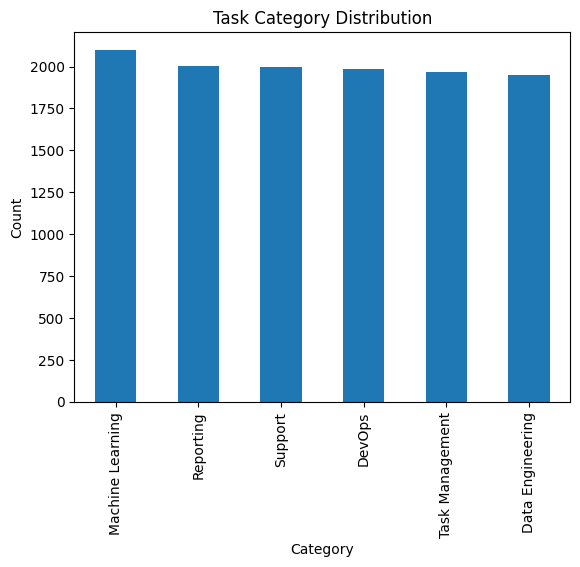

In [8]:
import matplotlib.pyplot as plt

df['task_category'].value_counts().plot(kind='bar')
plt.title("Task Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

# **Text Preprocessing (NLP)**

In [9]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)

    words = text.split()
    words = [stemmer.stem(w) for w in words if w not in stop_words]

    return " ".join(words)

df['clean_text'] = df['task_description'].apply(preprocess)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# **Train-Test Split**

In [10]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['task_category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **Feature Extraction (TF-IDF)**

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=7000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# **Naive Bayes Model**

In [12]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_test_pred_nb = nb_model.predict(X_test_tfidf)
y_train_pred_nb = nb_model.predict(X_train_tfidf)

print("NB test accuracy:", accuracy_score(y_test, y_test_pred_nb))
print("NB train accuracy:",accuracy_score(y_train,y_train_pred_nb))
print(classification_report(y_test, y_test_pred_nb))

NB test accuracy: 1.0
NB train accuracy: 1.0
                  precision    recall  f1-score   support

Data Engineering       1.00      1.00      1.00       367
          DevOps       1.00      1.00      1.00       401
Machine Learning       1.00      1.00      1.00       425
       Reporting       1.00      1.00      1.00       415
         Support       1.00      1.00      1.00       400
 Task Management       1.00      1.00      1.00       392

        accuracy                           1.00      2400
       macro avg       1.00      1.00      1.00      2400
    weighted avg       1.00      1.00      1.00      2400



# **SVM Model (Main Model)**

In [13]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(C=1.5)
svm_model.fit(X_train_tfidf, y_train)

y_test_pred_svm = svm_model.predict(X_test_tfidf)
y_train_pred_svm = svm_model.predict(X_train_tfidf)

print("SVM test accuracy:", accuracy_score(y_test, y_test_pred_svm))
print("SVM train accuracy:", accuracy_score(y_train, y_train_pred_svm))
print(classification_report(y_test, y_test_pred_svm))

SVM test accuracy: 1.0
SVM train accuracy: 1.0
                  precision    recall  f1-score   support

Data Engineering       1.00      1.00      1.00       367
          DevOps       1.00      1.00      1.00       401
Machine Learning       1.00      1.00      1.00       425
       Reporting       1.00      1.00      1.00       415
         Support       1.00      1.00      1.00       400
 Task Management       1.00      1.00      1.00       392

        accuracy                           1.00      2400
       macro avg       1.00      1.00      1.00      2400
    weighted avg       1.00      1.00      1.00      2400



# **Hyperparameter Tuning**

In [14]:
from sklearn.model_selection import GridSearchCV

params = {'C': [0.5, 1, 1.5, 2]}

grid = GridSearchCV(LinearSVC(), params, cv=3)
grid.fit(X_train_tfidf, y_train)

print(grid.best_params_)

{'C': 0.5}


# **Priority Prediction**

In [15]:
def assign_priority(row):
    if row['deadline_in_days'] <= 3:
        return "High"
    elif row['deadline_in_days'] <= 10:
        return "Medium"
    else:
        return "Low"

df['priority'] = df.apply(assign_priority, axis=1)

# **Priority Model**

In [16]:
from sklearn.ensemble import RandomForestClassifier

features = [
    'deadline_in_days',
    'estimated_effort_hours',
    'employee_current_workload_hours',
    'employee_past_completion_rate'
]

X_p = df[features]
y_p = df['priority']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_p, y_p, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_p, y_train_p)

y_pred_p = rf.predict(X_test_p)

print("Priority Accuracy:", accuracy_score(y_test_p, y_pred_p))

Priority Accuracy: 1.0


In [17]:
df.head()

,task_id,task_description,task_category,assigned_employee,task_created_date,deadline_in_days,estimated_effort_hours,employee_current_workload_hours,employee_past_completion_rate,clean_text,priority
0,1,setup CI/CD using Python,DevOps,EMP_22,2024-08-21,22,23,52,0.53,setup cicd use python,Low
1,2,monitor system using Python,DevOps,EMP_26,2024-08-16,27,11,18,0.64,monitor system use python,Low
2,3,assign tasks using Python,Task Management,EMP_20,2024-10-01,11,32,100,0.84,assign task use python,Low
3,4,manage cloud using Python,DevOps,EMP_37,2024-10-29,2,23,16,0.92,manag cloud use python,High
4,5,prepare report using Python,Reporting,EMP_1,2024-12-19,7,19,40,0.66,prepar report use python,Medium


# **Workload Balancing Logic**

In [18]:
def assign_employee(task_effort):

    # Getting latest workload per employee
    emp_df = df[['assigned_employee', 'employee_current_workload_hours']].copy()

    # Simulating adding new task effort
    emp_df['updated_workload'] = emp_df['employee_current_workload_hours'] + task_effort

    # Sorting by lowest workload
    emp_df = emp_df.sort_values('updated_workload')

    # Picking best employee (least workload)
    return emp_df.iloc[0]['assigned_employee']

# **Saved Models**

In [19]:
import joblib

# Save models
joblib.dump(svm_model, "svm_model.joblib")
joblib.dump(tfidf, "tfidf_vectorizer.joblib")
joblib.dump(rf, "priority_model.joblib")

['priority_model.joblib']